# EDA — dengue_treated.parquet
Análise exploratória dos dados tratados de pacientes internados com dengue (SINAN 2020–2024).

In [50]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import chi2_contingency

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

DATA_PATH = '../../data/processed/dengue_treated.parquet'
df = pd.read_parquet(DATA_PATH, engine='pyarrow')
print(f'Shape: {df.shape}')
display(df.dtypes.value_counts().rename('colunas por dtype').to_frame())

Shape: (298277, 52)


,colunas por dtype
float32,46
float64,4
object,2


In [51]:
BINARY_COLS = [
    'FEBRE','MIALGIA','CEFALEIA','EXANTEMA','VOMITO','NAUSEA',
    'DOR_COSTAS','CONJUNTVIT','ARTRITE','ARTRALGIA','PETEQUIA_N',
    'LEUCOPENIA','LACO','DOR_RETRO','DIABETES','HEMATOLOG',
    'HEPATOPAT','RENAL','HIPERTENSA','AUTO_IMUNE',
    'ALRM_HIPOT','ALRM_PLAQ','ALRM_VOM','ALRM_SANG','ALRM_HEMAT',
    'ALRM_ABDOM','ALRM_LETAR','ALRM_HEPAT','ALRM_LIQ',
    'GRAV_PULSO','GRAV_CONV','GRAV_ENCH','GRAV_INSUF','GRAV_TAQUI',
    'GRAV_EXTRE','GRAV_HIPOT','GRAV_HEMAT','GRAV_MELEN','GRAV_METRO',
    'GRAV_SANG','GRAV_AST','GRAV_MIOC','GRAV_CONSC','GRAV_ORGAO',
]
BINARY_COLS = [c for c in BINARY_COLS if c in df.columns]

ALRM_COLS = [c for c in BINARY_COLS if c.startswith('ALRM_')]
GRAV_COLS = [c for c in BINARY_COLS if c.startswith('GRAV_')]

display(df.head())

,CS_SEXO,CS_GESTANT,CS_RACA,CS_ESCOL_N,SG_UF,FEBRE,MIALGIA,CEFALEIA,EXANTEMA,VOMITO,...,GRAV_MELEN,GRAV_METRO,GRAV_SANG,GRAV_AST,GRAV_MIOC,GRAV_CONSC,GRAV_ORGAO,target,age_years,epi_week
0,M,6.0,1.0,NaN,41,1.0,1.0,1.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,62.0,3.0
1,F,NaN,NaN,NaN,41,1.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,44.0,15.0
2,F,5.0,1.0,6.0,41,1.0,1.0,1.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,60.0,8.0
3,F,5.0,1.0,7.0,41,1.0,1.0,1.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,18.0,6.0
4,F,5.0,1.0,3.0,41,1.0,1.0,1.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,58.0,4.0


## 2. Distribuição do target

In [52]:
# Colunas numéricas: count, mean, std, min, percentis, max
display(df.describe(include=[float, int]).T.round(3))

,count,mean,std,min,25%,50%,75%,max
CS_GESTANT,282492.0,5.568,0.669,1.000,5.0,6.0,6.0,6.0
CS_RACA,261493.0,2.349,1.462,1.000,1.0,1.0,4.0,5.0
CS_ESCOL_N,159735.0,5.575,2.868,0.000,3.0,6.0,8.0,10.0
FEBRE,298277.0,0.838,0.369,0.000,1.0,1.0,1.0,1.0
MIALGIA,298277.0,0.746,0.435,0.000,0.0,1.0,1.0,1.0
CEFALEIA,298277.0,0.676,0.468,0.000,0.0,1.0,1.0,1.0
EXANTEMA,298277.0,0.143,0.350,0.000,0.0,0.0,0.0,1.0
VOMITO,298277.0,0.374,0.484,0.000,0.0,0.0,1.0,1.0
NAUSEA,298277.0,0.456,0.498,0.000,0.0,0.0,1.0,1.0
DOR_COSTAS,298277.0,0.239,0.427,0.000,0.0,0.0,0.0,1.0


## 3. Distribuição de idade (age_years)

count    297970.0
mean         40.3
std          24.9
min           0.0
25%          19.0
50%          39.0
75%          60.0
max         408.0

Moda: 9 anos
Assimetria: 0.32  |  Curtose: 0.89


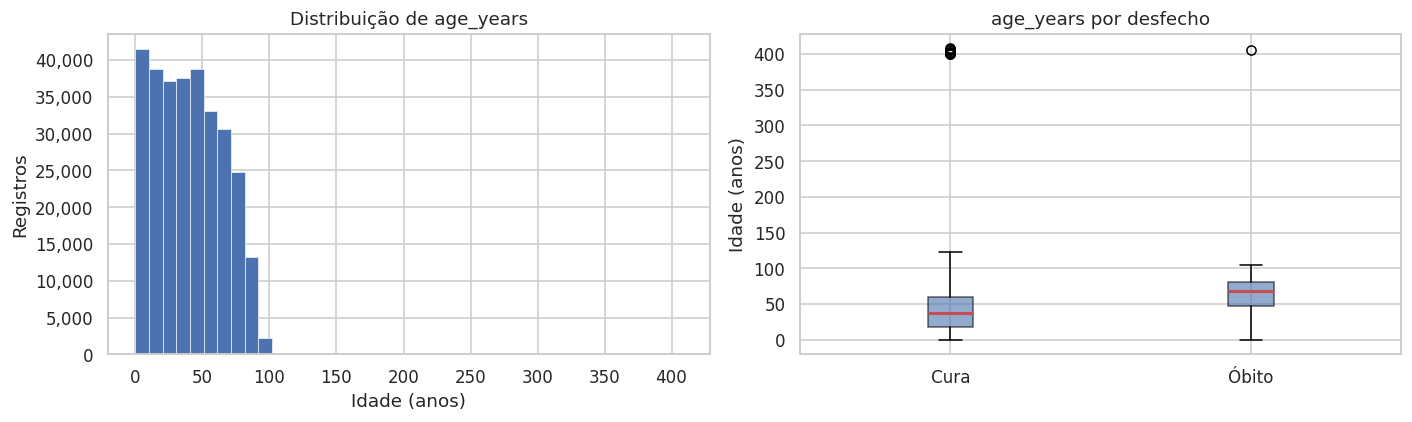

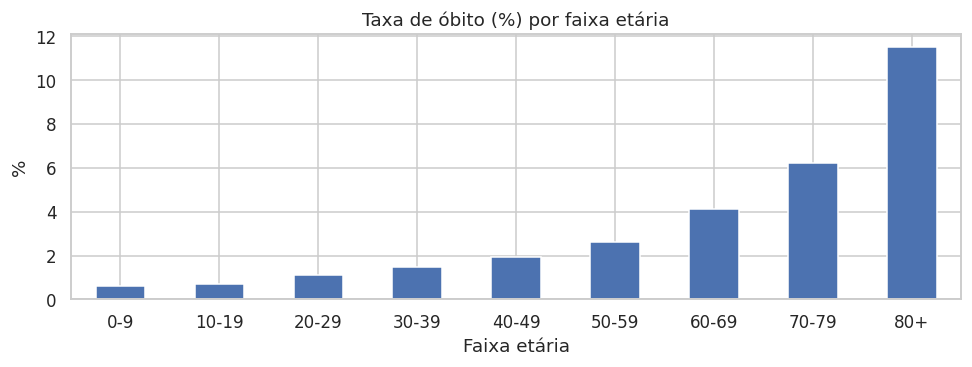

In [53]:
if 'age_years' not in df.columns:
    print('AVISO: age_years não encontrada. Execute clean_data.py e treat_data.py novamente.')
else:
    age = df['age_years'].dropna()
    print(age.describe().round(1).to_string())
    print(f'\nModa: {age.mode().iloc[0]:.0f} anos')
    print(f'Assimetria: {age.skew():.2f}  |  Curtose: {age.kurt():.2f}')

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Histograma geral
    axes[0].hist(age, bins=40, color='#4C72B0', edgecolor='white', linewidth=0.4)
    axes[0].set_title('Distribuição de age_years')
    axes[0].set_xlabel('Idade (anos)')
    axes[0].set_ylabel('Registros')
    axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

    # Boxplot por desfecho
    df_age = df[['age_years', 'target']].dropna()
    df_age['desfecho'] = df_age['target'].map({0.0: 'Cura', 1.0: 'Óbito'})
    grupos = [g['age_years'].values for _, g in df_age.groupby('desfecho')]
    labels  = [name for name, _ in df_age.groupby('desfecho')]
    axes[1].boxplot(grupos, labels=labels, patch_artist=True,
                    boxprops=dict(facecolor='#4C72B0', alpha=0.6),
                    medianprops=dict(color='#C44E52', linewidth=2))
    axes[1].set_title('age_years por desfecho')
    axes[1].set_ylabel('Idade (anos)')

    plt.tight_layout()
    plt.show()

    # Taxa de óbito por faixa etária
    df_age['faixa'] = pd.cut(df_age['age_years'], bins=[0,10,20,30,40,50,60,70,80,120],
                              labels=['0-9','10-19','20-29','30-39','40-49','50-59','60-69','70-79','80+'])
    taxa_faixa = df_age.groupby('faixa', observed=True)['target'].mean().mul(100)

    fig, ax = plt.subplots(figsize=(9, 3.5))
    taxa_faixa.plot.bar(ax=ax, color='#4C72B0')
    ax.set_title('Taxa de óbito (%) por faixa etária')
    ax.set_xlabel('Faixa etária')
    ax.set_ylabel('%')
    ax.tick_params(axis='x', rotation=0)
    plt.tight_layout()
    plt.show()

In [54]:
# Colunas categóricas (object): count, unique, moda (top), freq
cat_cols = df.select_dtypes(include='object').columns.tolist()
if cat_cols:
    display(df[cat_cols].describe())

,CS_SEXO,SG_UF
count,298275,298277
unique,3,27
top,F,35
freq,160585,71745


In [55]:
# Moda de todas as colunas
display(df.mode().iloc[0].rename('moda').to_frame())

,moda
CS_SEXO,F
CS_GESTANT,6.0
CS_RACA,1.0
CS_ESCOL_N,6.0
SG_UF,35
FEBRE,1.0
MIALGIA,1.0
CEFALEIA,1.0
EXANTEMA,0.0
VOMITO,0.0


## 1. Distribuição do target

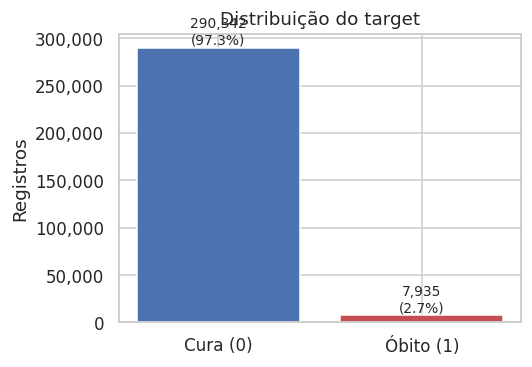

target
Cura (0)     290342
Óbito (1)      7935


In [56]:
counts = df['target'].value_counts(dropna=False).rename({0.0: 'Cura (0)', 1.0: 'Óbito (1)'})
total  = len(df)

fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(counts.index.astype(str), counts.values, color=['#4C72B0', '#C44E52', '#999'])
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 300,
            f'{val:,}\n({val / total * 100:.1f}%)', ha='center', va='bottom', fontsize=9)
ax.set_title('Distribuição do target')
ax.set_ylabel('Registros')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()
print(counts.to_string())

## 2. Valores ausentes por feature

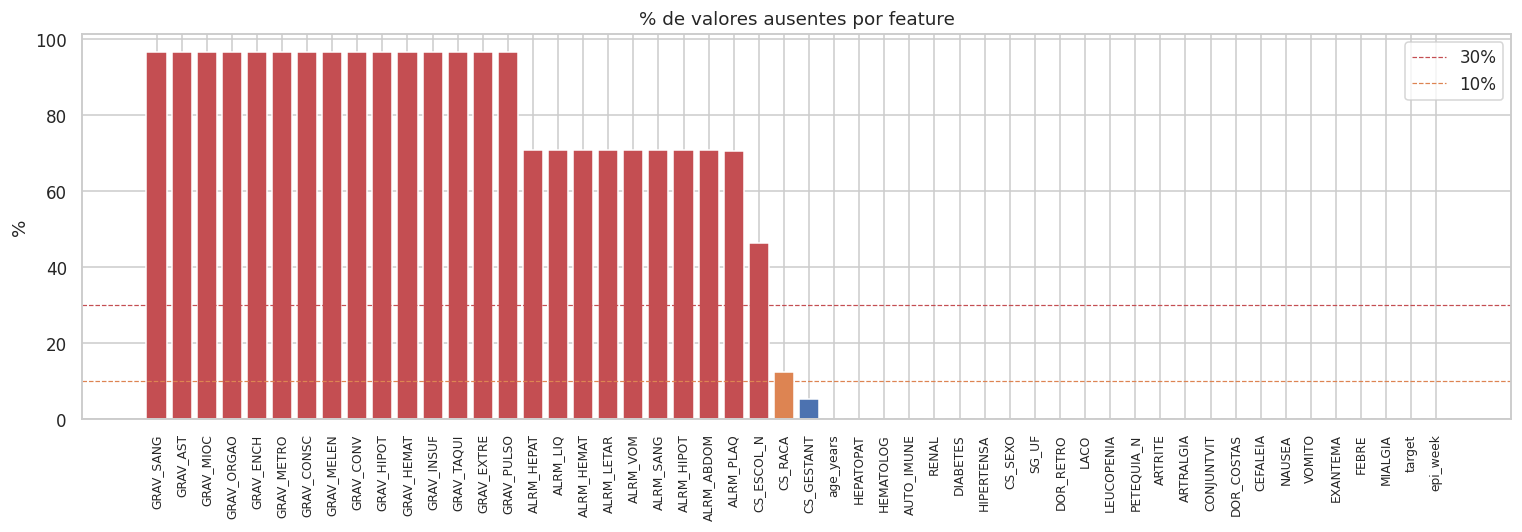

,feature,pct_missing
0,GRAV_SANG,96.578013
1,GRAV_AST,96.576337
2,GRAV_MIOC,96.576337
3,GRAV_ORGAO,96.575331
4,GRAV_ENCH,96.572314
5,GRAV_METRO,96.569632
6,GRAV_CONSC,96.567285
7,GRAV_MELEN,96.566950
8,GRAV_CONV,96.564938
9,GRAV_HIPOT,96.563932


In [57]:
missing = (
    df.isnull().mean().mul(100)
    .sort_values(ascending=False)
    .rename('pct_missing')
)

fig, ax = plt.subplots(figsize=(14, 5))
colors = ['#C44E52' if v > 30 else '#DD8452' if v > 10 else '#4C72B0' for v in missing.values]
ax.bar(missing.index, missing.values, color=colors)
ax.axhline(30, color='#C44E52', linestyle='--', linewidth=0.8, label='30%')
ax.axhline(10, color='#DD8452', linestyle='--', linewidth=0.8, label='10%')
ax.set_title('% de valores ausentes por feature')
ax.set_ylabel('%')
ax.set_xticklabels(missing.index, rotation=90, fontsize=8)
ax.legend()
plt.tight_layout()
plt.show()

display(missing.reset_index().rename(columns={'index': 'feature'}))

## 3. Distribuição de epi_week

Range: 1 – 53 | Fora de [1,53]: 0


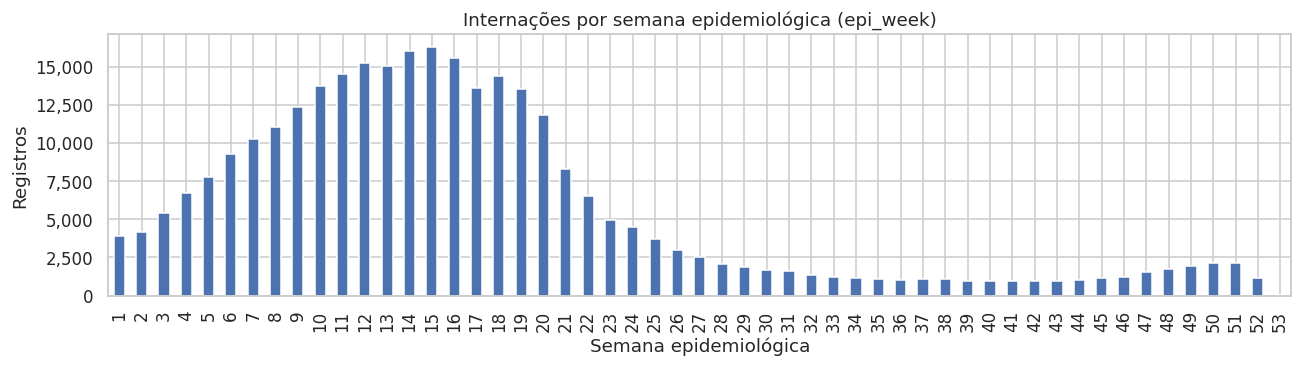

In [58]:
if 'epi_week' in df.columns:
    ew = df['epi_week'].dropna().astype(int)
    print(f'Range: {ew.min()} – {ew.max()} | Fora de [1,53]: {((ew < 1) | (ew > 53)).sum()}')

    fig, ax = plt.subplots(figsize=(12, 3.5))
    ew.value_counts().sort_index().plot.bar(ax=ax, color='#4C72B0')
    ax.set_title('Internações por semana epidemiológica (epi_week)')
    ax.set_xlabel('Semana epidemiológica')
    ax.set_ylabel('Registros')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    plt.tight_layout()
    plt.show()

## 4. Valores inesperados nas colunas binárias
Após tratamento, os únicos valores válidos são `0`, `1` e `NaN`.

In [59]:
rows = []
for col in BINARY_COLS:
    n_invalid = (~df[col].isin([0.0, 1.0]) & df[col].notna()).sum()
    rows.append({'feature': col, 'n_inválidos': n_invalid, 'valores_únicos': sorted(df[col].dropna().unique().tolist())})

df_invalid = pd.DataFrame(rows).sort_values('n_inválidos', ascending=False)
problemas = df_invalid[df_invalid['n_inválidos'] > 0]
if problemas.empty:
    print('Nenhum valor inesperado — todas as colunas binárias contêm apenas 0, 1 ou NaN.')
else:
    display(problemas)

Nenhum valor inesperado — todas as colunas binárias contêm apenas 0, 1 ou NaN.


## 5. Correlação das features com o target
Taxa de óbito (target=1) para presença (1) vs ausência (0) de cada sinal clínico.

In [60]:
df_t = df.dropna(subset=['target']).copy()

rows = []
for col in BINARY_COLS:
    sub = df_t[[col, 'target']].dropna()
    if sub.empty or sub[col].nunique() < 2:
        continue
    rate_sim = sub.loc[sub[col] == 1, 'target'].mean()
    rate_nao = sub.loc[sub[col] == 0, 'target'].mean()
    ct = pd.crosstab(sub[col], sub['target'])
    chi2, p, _, _ = chi2_contingency(ct)
    rows.append({
        'feature':         col,
        'taxa_obito_sim':  round(rate_sim * 100, 2),
        'taxa_obito_nao':  round(rate_nao * 100, 2),
        'delta_pp':        round((rate_sim - rate_nao) * 100, 2),
        'chi2':            round(chi2, 1),
        'p_valor':         round(p, 4),
    })

df_corr = pd.DataFrame(rows).sort_values('delta_pp', ascending=False)
display(df_corr)

,feature,taxa_obito_sim,taxa_obito_nao,delta_pp,chi2,p_valor
29,GRAV_PULSO,88.089996,40.169998,47.919998,1630.2,0.0000
34,GRAV_EXTRE,79.760002,35.590000,44.180000,1812.8,0.0000
42,GRAV_CONSC,77.610001,36.040001,41.570000,1628.2,0.0000
35,GRAV_HIPOT,80.959999,40.299999,40.660000,1306.9,0.0000
31,GRAV_ENCH,80.029999,44.330002,35.700001,777.3,0.0000
30,GRAV_CONV,79.589996,47.139999,32.450001,434.1,0.0000
43,GRAV_ORGAO,73.230003,46.070000,27.160000,446.0,0.0000
32,GRAV_INSUF,71.809998,44.669998,27.139999,532.4,0.0000
33,GRAV_TAQUI,67.940002,41.450001,26.490000,658.2,0.0000
39,GRAV_SANG,76.629997,50.230000,26.400000,77.8,0.0000


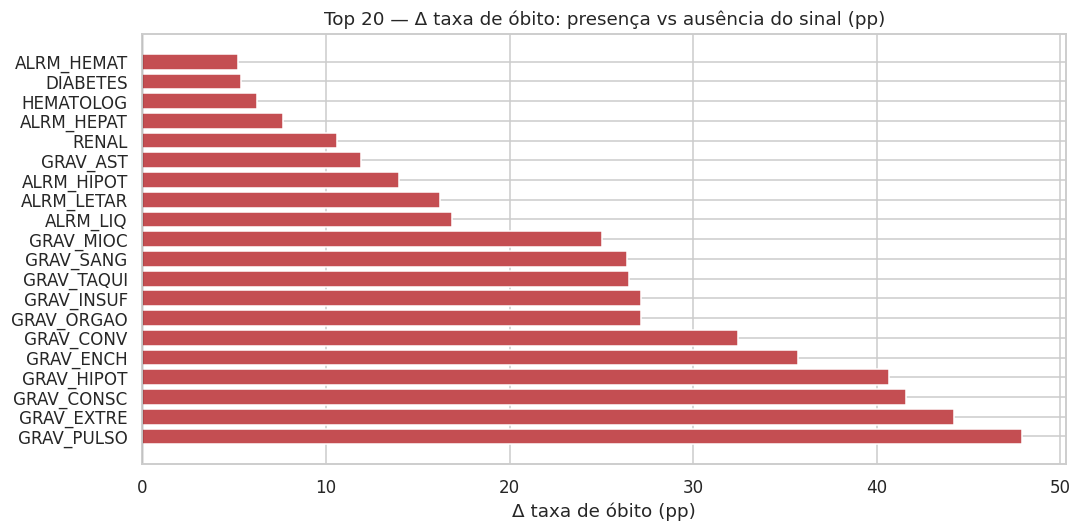

In [61]:
top = df_corr.dropna(subset=['delta_pp']).head(20)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#C44E52' if v > 0 else '#4C72B0' for v in top['delta_pp']]
ax.barh(top['feature'], top['delta_pp'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 20 — Δ taxa de óbito: presença vs ausência do sinal (pp)')
ax.set_xlabel('Δ taxa de óbito (pp)')
plt.tight_layout()
plt.show()

## 6. Taxa de óbito por variável demográfica

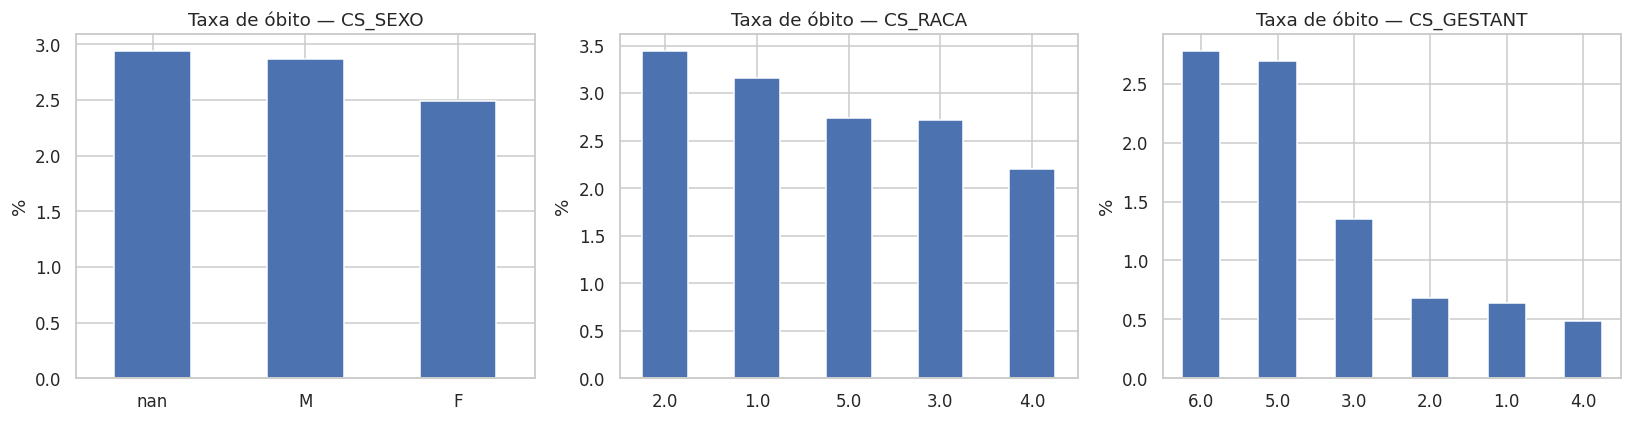

In [62]:
demo_cols = [c for c in ['CS_SEXO', 'CS_RACA', 'CS_GESTANT'] if c in df_t.columns]
fig, axes = plt.subplots(1, len(demo_cols), figsize=(5 * len(demo_cols), 4))
if len(demo_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, demo_cols):
    sub = df_t[[col, 'target']].dropna()
    rate = sub.groupby(col)['target'].mean().mul(100).sort_values(ascending=False)
    rate.plot.bar(ax=ax, color='#4C72B0')
    ax.set_title(f'Taxa de óbito — {col}')
    ax.set_ylabel('%')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 7. Matriz de correlação entre features

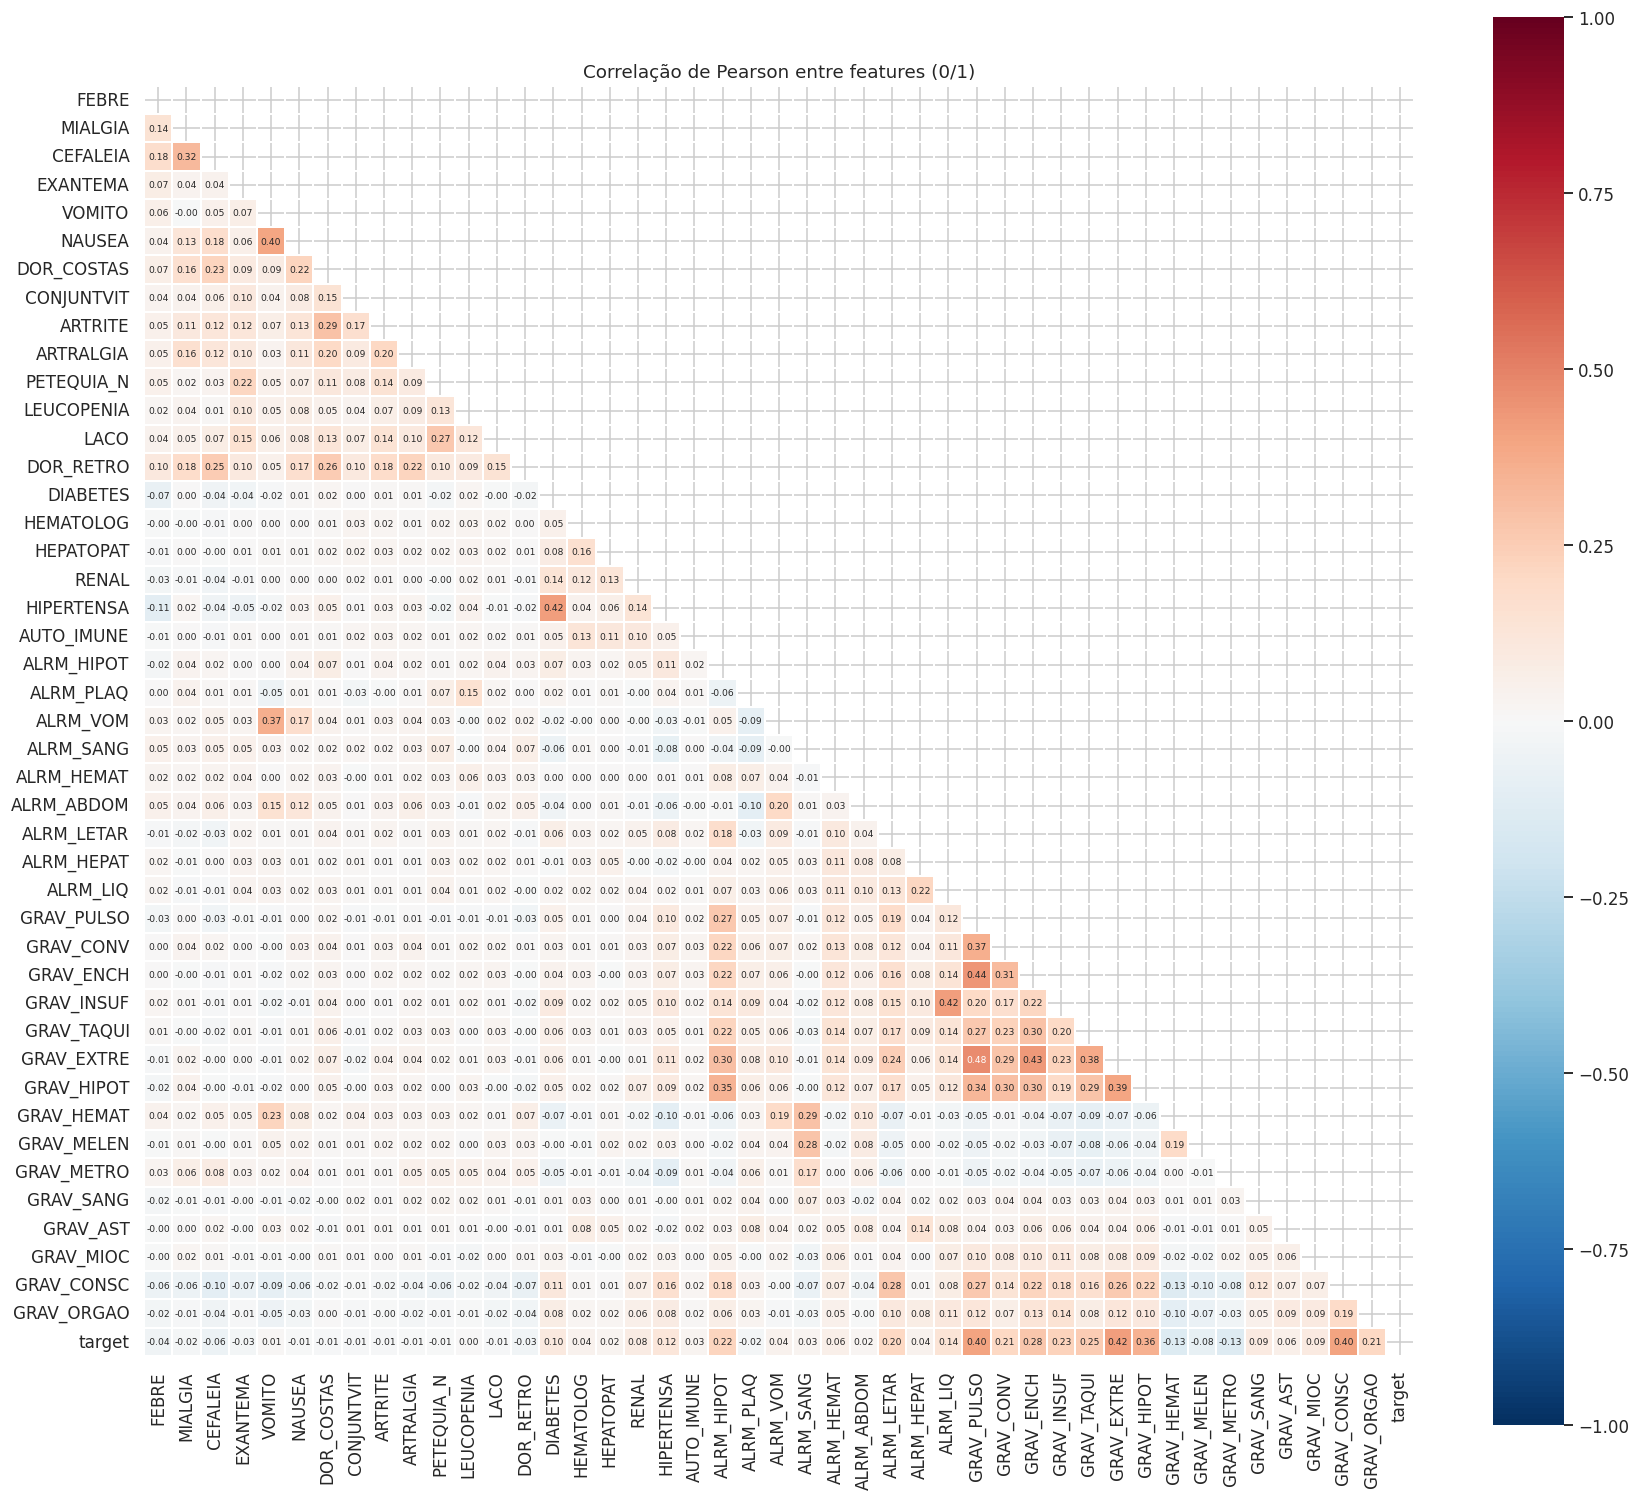

In [63]:
corr_cols = BINARY_COLS + ['target']
corr = df_t[corr_cols].corr(method='pearson', numeric_only=True)

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, ax=ax,
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 6},
    linewidths=0.3, square=True,
)
ax.set_title('Correlação de Pearson entre features (0/1)')
plt.tight_layout()
plt.show()

## 8. Correlação de cada feature com o target

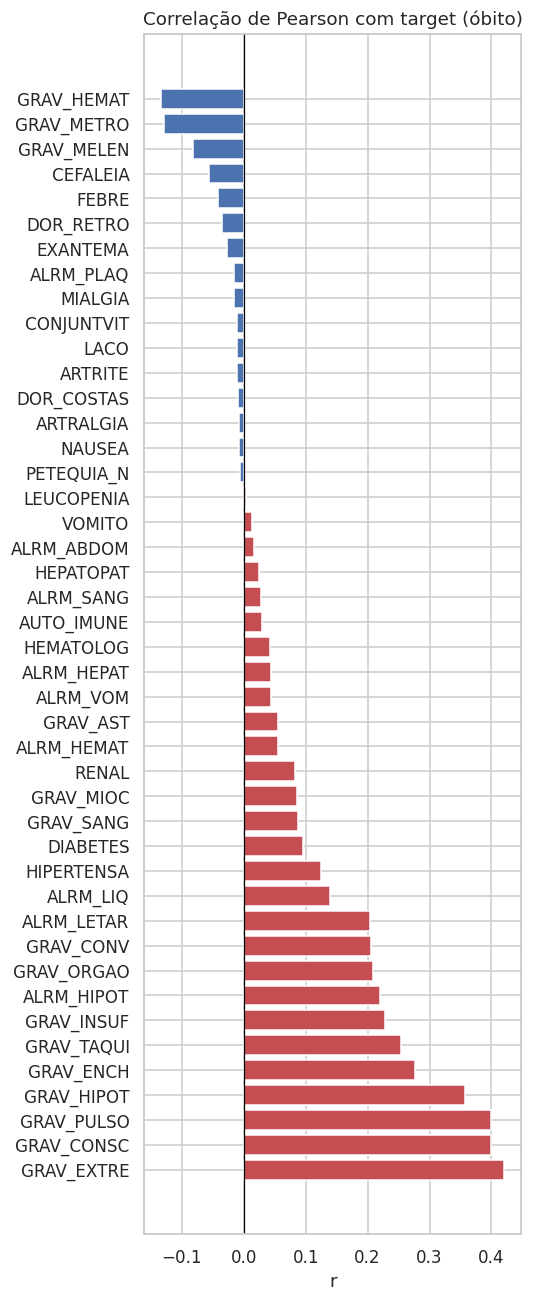

Top correlações positivas:
GRAV_EXTRE    0.420612
GRAV_CONSC    0.398973
GRAV_PULSO    0.398596
GRAV_HIPOT    0.357309
GRAV_ENCH     0.275985
GRAV_TAQUI    0.253601
GRAV_INSUF    0.228125
ALRM_HIPOT    0.220079
GRAV_ORGAO    0.209197
GRAV_CONV     0.206142

Top correlações negativas:
CONJUNTVIT   -0.010256
MIALGIA      -0.016228
ALRM_PLAQ    -0.016359
EXANTEMA     -0.027302
DOR_RETRO    -0.034690
FEBRE        -0.041404
CEFALEIA     -0.056458
GRAV_MELEN   -0.081393
GRAV_METRO   -0.129184
GRAV_HEMAT   -0.133115


In [64]:
target_corr = corr['target'].drop('target').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(5, 12))
colors = ['#C44E52' if v > 0 else '#4C72B0' for v in target_corr.values]
ax.barh(target_corr.index, target_corr.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlação de Pearson com target (óbito)')
ax.set_xlabel('r')
plt.tight_layout()
plt.show()

print('Top correlações positivas:')
print(target_corr.head(10).to_string())
print('\nTop correlações negativas:')
print(target_corr.tail(10).to_string())

## 9. Presença dos sinais de alarme e gravidade por desfecho

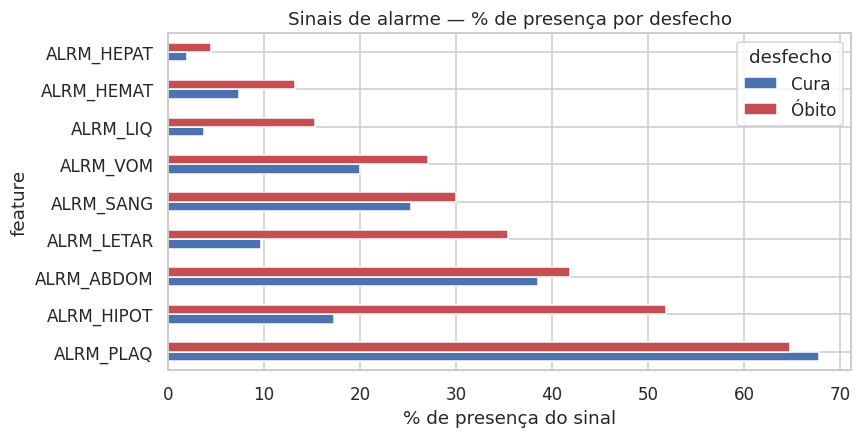

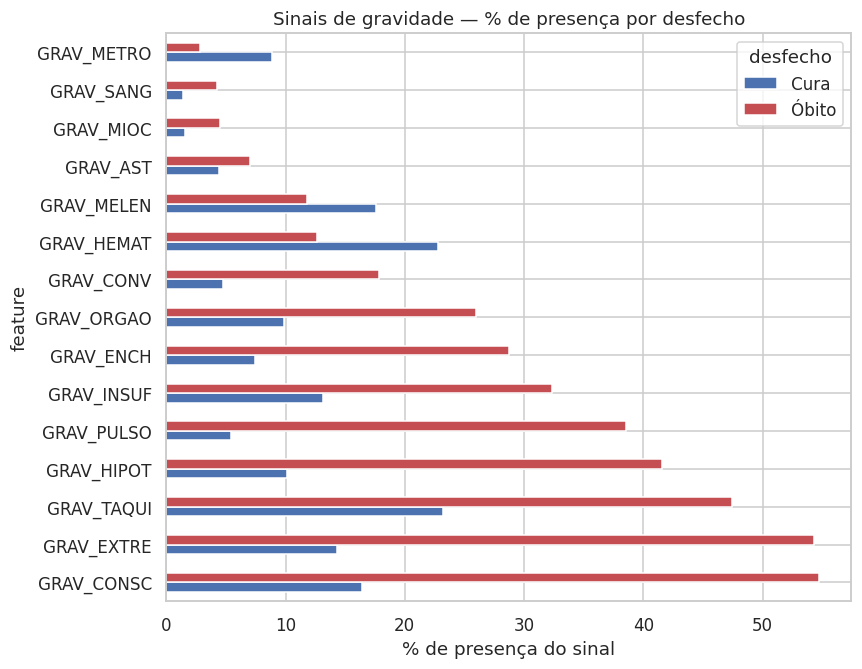

In [65]:
def plot_presenca_por_desfecho(cols, title):
    rows = []
    for col in cols:
        sub = df_t[[col, 'target']].dropna()
        for desfecho, label in [(0, 'Cura'), (1, 'Óbito')]:
            rate = sub.loc[sub['target'] == desfecho, col].mean() * 100
            rows.append({'feature': col, 'desfecho': label, 'presença (%)': rate})
    df_p = pd.DataFrame(rows).pivot(index='feature', columns='desfecho', values='presença (%)').sort_values('Óbito', ascending=False)
    ax = df_p.plot.barh(figsize=(8, len(cols) * 0.35 + 1), color=['#4C72B0', '#C44E52'])
    ax.set_title(title)
    ax.set_xlabel('% de presença do sinal')
    plt.tight_layout()
    plt.show()

plot_presenca_por_desfecho(ALRM_COLS, 'Sinais de alarme — % de presença por desfecho')
plot_presenca_por_desfecho(GRAV_COLS, 'Sinais de gravidade — % de presença por desfecho')

## 10. Decisões de pré-processamento para o pipeline de ML

> **Estas decisões NÃO são aplicadas ao dataset.** Elas configuram o `ColumnTransformer`
> dentro de cada pipeline de modelo, **após o train/test split**, evitando data leakage.

### Problemas identificados e decisões

| Problema | Feature(s) | Decisão | Justificativa |
|---|---|---|---|
| Outlier de idade (máx=408) | `age_years` | `> 120 → NaN` → `SimpleImputer(median)` | Artefato de encoding SINAN |
| ~97% NaN informativo | `GRAV_*` (10k preenchidos) | `SimpleImputer(constant, fill_value=0)` | Ausência = paciente sem dengue grave |
| ~71% NaN informativo | `ALRM_*` (87k preenchidos) | `SimpleImputer(constant, fill_value=0)` | Ausência = paciente sem sinais de alarme |
| 3 categorias | `CS_SEXO` (M/F/NaN) | `OrdinalEncoder` M→1/F→0 + `SimpleImputer(most_frequent)` | NaN < 0.01% |
| ~46% NaN | `CS_ESCOL_N` | `SimpleImputer(median)` ou passthrough | Dependente do modelo |
| NaN em ordinals | `CS_GESTANT`, `CS_RACA` | `SimpleImputer(median)` ou passthrough | Dependente do modelo |

### Estratégia por tipo de modelo

| Modelo | GRAV_*/ALRM_* NaN | Demais NaN | Observação |
|---|---|---|---|
| XGBoost / LightGBM / CatBoost | `fill=0` | passthrough nativo | Suportam NaN internamente |
| Logistic Regression / SVM | `fill=0` | `SimpleImputer(median/mode)` | Exigem dados completos |
| Random Forest (sklearn) | `fill=0` | `SimpleImputer(median/mode)` | Exigem dados completos |

In [ ]:
from sklearn.pdevipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer

ALRM_COLS_ = [c for c in df.columns if c.startswith('ALRM_')]
GRAV_COLS_  = [c for c in df.columns if c.startswith('GRAV_')]

# Referência de ColumnTransformer — a ser instanciado em cada notebook de modelo
preprocessor = ColumnTransformer(
    transformers=[
        # age_years: clip outliers antes (feito inline no notebook de modelo), depois mediana
        ('age_imputer',
         SimpleImputer(strategy='median'),
         ['age_years']),

        # ALRM_* e GRAV_*: ausência informativa → 0
        ('alarm_gravity_fill',
         SimpleImputer(strategy='constant', fill_value=0),
         ALRM_COLS_ + GRAV_COLS_),

        # CS_SEXO: encode M→1/F→0, NaN → moda
        ('sexo',
         Pipeline([
             ('enc', OrdinalEncoder(categories=[['F', 'M']], handle_unknown='use_encoded_value', unknown_value=np.nan)),
             ('imp', SimpleImputer(strategy='most_frequent')),
         ]),
         ['CS_SEXO']),

        # Ordinais com NaN — mediana (para modelos que não suportam NaN)
        ('ordinal_imputer',
         SimpleImputer(strategy='median'),
         ['CS_GESTANT', 'CS_RACA', 'CS_ESCOL_N']),
    ],
    remainder='passthrough',  # demais features passam direto (tree-based toleram NaN)
    verbose_feature_names_out=False,
)

print('ColumnTransformer de referência definido.')
print('Adapte o `remainder` conforme o modelo:')
print('  - tree-based (XGB/LGBM): remainder="passthrough"')
print('  - lineares/SVM:          remainder=SimpleImputer(strategy="median")')